# Predicting House Sale Prices in Ames, Iowa
---

 ## Dataset Attributes

 The dataset contains information about houses in Ames, Iowa. The data was collected by the Ames City Assessor’s Office describing 2930 property sales which occurred in Ames, Iowa between 2006 and 2010. The dataset, containing 81 variables, was compiled and published by De Cock in 2011.

 Some of the variables contained in the original dataset have been removed from the the dataset provided to you.
 The dataset provided to you contains the following variables:
* **Year_Built:** year that the house was originally constructed
* **Year_Remod_Add:** year that the house was last remodelled
* **Total_Bsmt_SF:** total size of basement area in square feet
* **First_Flr_SF:** size of the first floor in square feet
* **Second_Flr_SF:** size of the second floor in square feet
* **Gr_Liv_Area:** size of above grade, ground living area in square feet
* **Full_Bath:** number of full above grade bathrooms in the house
* **Half_Bath:** number of half above grade bathrooms in the house
* **Bedroom_AbvGr:** number of above grade bedrooms (does not include basement bedrooms)
* **Kitchen_AbvGr:** number of above grade kitchens
* **TotRms_AbvGrd:** total number of above grade rooms (does not include bathrooms)
* **Fireplaces:** number of fireplaces in the house
* **Garage_Area:** size of garage in square feet
* **Sale_Price:** sale price of the house in dollars


*De Cock, D. (2011). "Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester
Regression Project," Journal of Statistics Education, Volume 19, Number 3.*

- https://ww2.amstat.org/publications/jse/v19n3/decock/DataDocumentation.txt
- http://ww2.amstat.org/publications/jse/v19n3/decock.pdf


---
## Objective

 The goal of this task is to analyse the relationship between these variables and build a multiple linear regression model to predict the sales prices based on the 'Gr_Liv_Area' and 'Garage_Area` variables.


---
## Import Libraries

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

---
## Load The Data

In [ ]:
# Read in the data set  
data = pd.read_csv('ames.csv')

,Year_Built,Year_Remod_Add,Total_Bsmt_SF,First_Flr_SF,Second_Flr_SF,Gr_Liv_Area,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,TotRms_AbvGrd,Fireplaces,Garage_Area,Sale_Price
0,1960,1960,1080,1656,0,1656,1,0,3,1,7,2,528,215000
1,1961,1961,882,896,0,896,1,0,2,1,5,0,730,105000
2,1958,1958,1329,1329,0,1329,1,1,3,1,6,0,312,172000
3,1968,1968,2110,2110,0,2110,2,1,3,1,8,2,522,244000
4,1997,1998,928,928,701,1629,2,1,3,1,6,1,482,189900


---
## Preview The Data

In [ ]:
# Display the first few rows of the dataset
data.head()

# Quick inspection
print("Basic information about the dataset:")
print(data.info())
print("Statistics of the dataset:")
print(data.describe())

# Check for missing values
print("Missing values in each column:")
print(data.isnull().sum())

# Check for Zero Values in Key Numeric Columns 
print("\nZero values in key numerical columns:")
zero_counts = (data[['Total_Bsmt_SF', 'First_Flr_SF', 'Second_Flr_SF', 
                     'Gr_Liv_Area', 'Garage_Area']] == 0).sum()
print(zero_counts)

Basic information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Year_Built      2930 non-null   int64
 1   Year_Remod_Add  2930 non-null   int64
 2   Total_Bsmt_SF   2930 non-null   int64
 3   First_Flr_SF    2930 non-null   int64
 4   Second_Flr_SF   2930 non-null   int64
 5   Gr_Liv_Area     2930 non-null   int64
 6   Full_Bath       2930 non-null   int64
 7   Half_Bath       2930 non-null   int64
 8   Bedroom_AbvGr   2930 non-null   int64
 9   Kitchen_AbvGr   2930 non-null   int64
 10  TotRms_AbvGrd   2930 non-null   int64
 11  Fireplaces      2930 non-null   int64
 12  Garage_Area     2930 non-null   int64
 13  Sale_Price      2930 non-null   int64
dtypes: int64(14)
memory usage: 320.6 KB
None
Statistics of the dataset:
        Year_Built  Year_Remod_Add  Total_Bsmt_SF  First_Flr_SF  \
count  2930.000000     2930.

---
## Data Exploration

Explore the data with visualisations such as histograms and correlation matrices

### Visualize Distributions

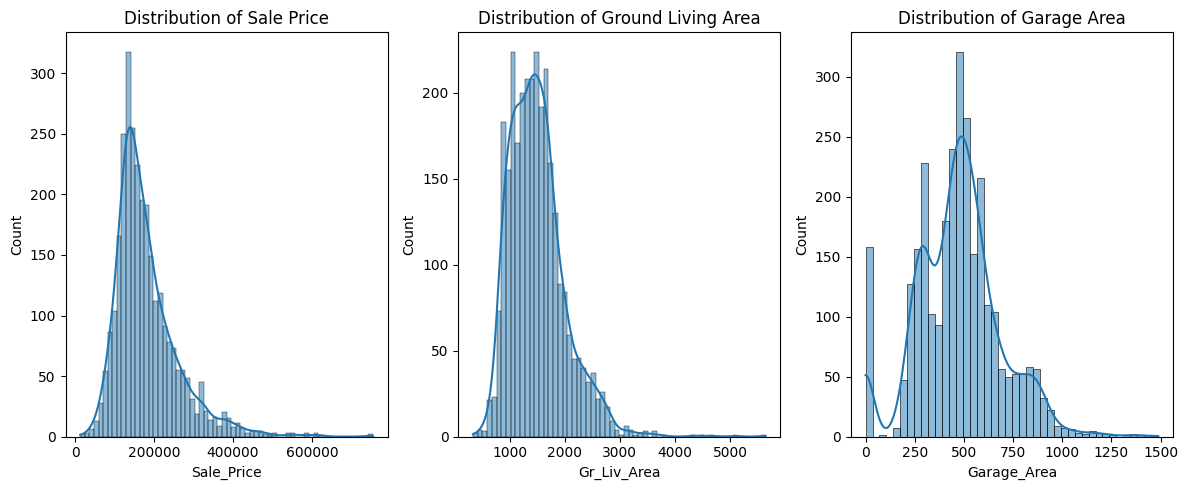

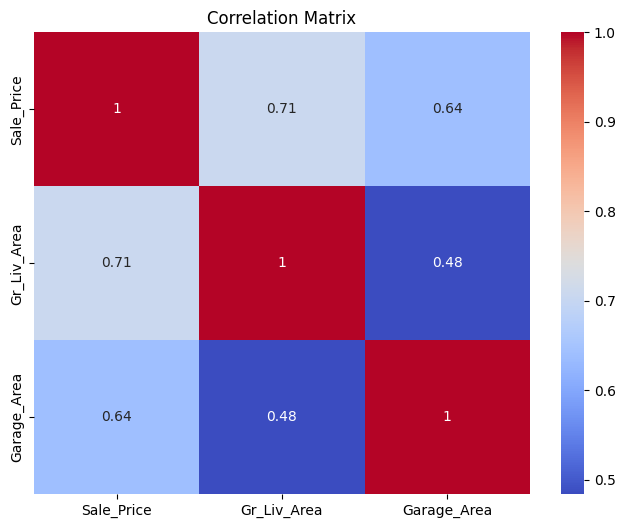

<function matplotlib.pyplot.show(close=None, block=None)>

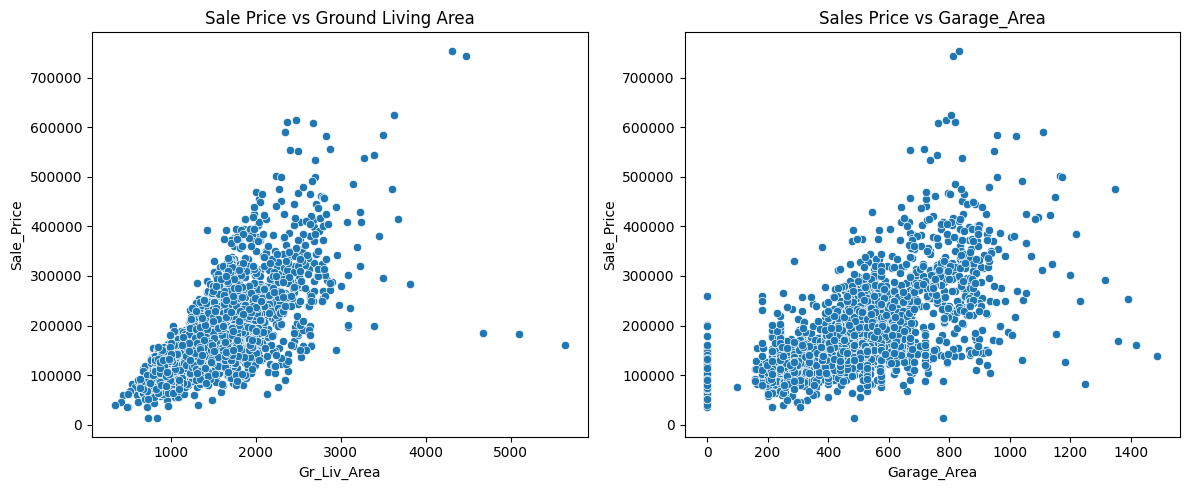

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
sns.histplot(data['Sale_Price'], kde=True)
plt.title('Distribution of Sale Price') 

plt.subplot(1, 3, 2)
sns.histplot(data['Gr_Liv_Area'], kde=True)
plt.title('Distribution of Ground Living Area')

plt.subplot(1, 3, 3)
sns.histplot(data['Garage_Area'], kde=True)
plt.title('Distribution of Garage Area')

plt.tight_layout()
plt.show()

### Correlation Matrix

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(data[['Sale_Price','Gr_Liv_Area','Garage_Area']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Scatterplots

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
sns.scatterplot(x='Gr_Liv_Area', y='Sale_Price', data=data)
plt.title('Sale Price vs Ground Living Area')

plt.subplot(1,2,2)
sns.scatterplot(x='Garage_Area', y='Sale_Price', data=data) 
plt.title('Sale Price vs Garage Area')

plt.tight_layout()
plt.show()

---
## Prepare Features And Target

In [6]:
# Split the independent variables from the dependent variable
X = data[['Gr_Liv_Area', 'Garage_Area']]
y = data['Sale_Price']

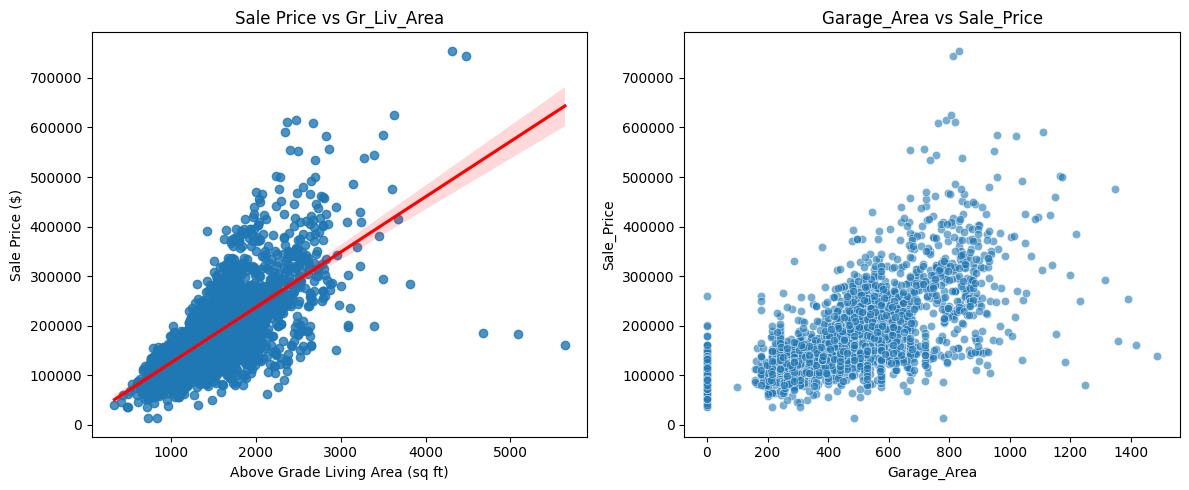

             Gr_Liv_Area  Garage_Area  Sale_Price
Gr_Liv_Area     1.000000     0.483971    0.706780
Garage_Area     0.483971     1.000000    0.640138
Sale_Price      0.706780     0.640138    1.000000


In [7]:
# Explore relationships between the independent and dependent variables
# Scatter plots with regression lines
plt.figure(figsize=(12,5))

# Gr_Liv_Area vs Sale_Price
plt.subplot(1,2,1)
sns.regplot(x='Gr_Liv_Area', y='Sale_Price', data=data, line_kws={'color':'red'})
plt.title('Sale Price vs Gr_Liv_Area')
plt.xlabel('Above Grade Living Area (sq ft)')
plt.ylabel('Sale Price ($)')

# Garage_Area vs Sale_Price
plt.subplot(1, 2, 2)
sns.scatterplot(data=data, x='Garage_Area', y='Sale_Price', alpha=0.6)
plt.title('Garage_Area vs Sale_Price')

plt.tight_layout()
plt.show()

# Correlation matrix
correlation = data[['Gr_Liv_Area', 'Garage_Area', 'Sale_Price']].corr()
print(correlation)

---
## Train-Test Split

In [8]:
# Create a training and test set with a 75:25 split ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

---
## Fit Linear Regression Model

In [9]:
# Build a multiple linear regression model using 'Gr_Liv_Area' and 'Garage_Area'
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


---
## Model Parameters

In [ ]:
# Print the model intercept and coefficients
print("\nLinear Regression Coefficients:")
print("Intercept:", model.intercept_)
for feature, coef in zip(X.columns, model.coef_):
    print(f"Coefficient for {feature}: {coef:.2f}")


Intercept: -5059.448195610428
Coefficient for Gr_Liv_Area: 78.69
Coefficient for Garage_Area: 141.15


---
## Predictions and Evaluation

### Predictions

In [11]:
# Generate predictions for the test set
y_pred = model.predict(X_test)

### Evaluate the model

In [ ]:
# Compute Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")

# Compute Root Mean Squared Error
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


Mean Squared Error (MSE): 2634371879.69
Root Mean Squared Error (RMSE): 51326.13


### Actual vs Predicted Plot

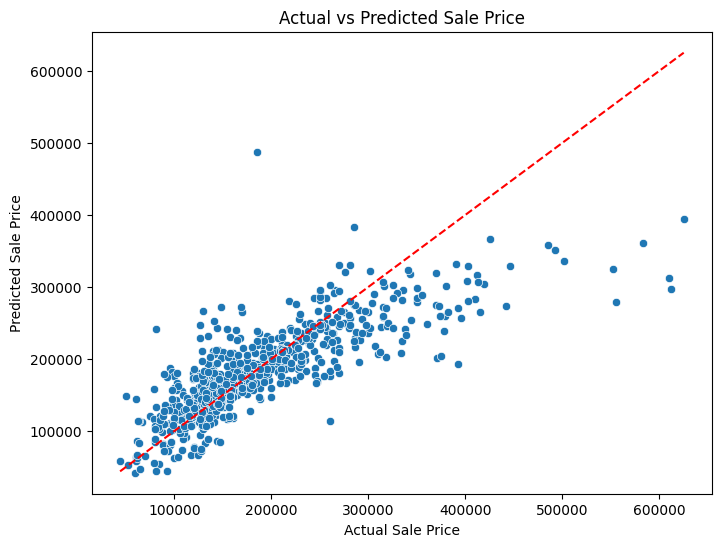

In [ ]:
# Error plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs Predicted Sale Price')
plt.show()

### Interpretation of Coefficients

In [14]:
# Print the coefficients
for feature, coef in zip(X.columns, model.coef_):
    print(f"Coefficient for {feature}: {coef:.2f}")

Coefficient for Gr_Liv_Area: 78.69
Coefficient for Garage_Area: 141.15


**Interpret coefficients in the context of the prediction:**
- The coefficient for Gr_Liv_Area(78.69) means:
  - For each additional square foot of living area, the sale price increases by about $79, assuming garage area stays the same.


- The coefficient for Garage_Area(141.15) means:
  - For each additional square foot of garage area, the sale price increases by about $141, assuming living area stays the same.

- This indicates that while both factors positively impact house prices, garage space surprisingly has a larger marginal effect per square foot than living space in this fitted model.  

---
## Summary of Findings

#### Distributions:

  - Sale_Price, Gr_Liv_Area, and Garage_Area are all right-skewed, meaning most homes are modest in size and price, with a tail of higher values.

#### Relationships:

  - Gr_Liv_Area has a strong positive correlation (≈ 0.71) with Sale_Price.

  - Garage_Area shows a moderate positive correlation (≈ 0.64).

#### Visual patterns:

  - Scatterplots confirm linear relationships, making multiple linear regression an appropriate choice.

#### Model performance:

  - The RMSE suggests the model predicts house prices with moderate error, reasonable given housing market variability.



